# Advanced Deep Learning – Lab 3.5


## Imports & Setup

In [6]:


import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import requests

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


---
# Task 3.5.1 – To Laugh or Not to Laugh
### Character-Level RNN with Embedding Layer for Joke Generation

## 3.5.1 (a) – Load and Preprocess the Jokes Dataset

In [7]:
url = ("https://raw.githubusercontent.com/Fraser-Greenlee/my-huggingface-datasets/"
       "master/data/short-jokes/train.txt")

response = requests.get(url)
raw_text = response.text
print(f"Raw text length: {len(raw_text)} characters")
print("First 300 chars:")
print(raw_text[:300])

Raw text length: 22111924 characters
First 300 chars:
[me narrating a documentary about narrators] ""I can't hear what they're saying cuz I'm talking""
Telling my daughter garlic is good for you. Good immune system and keeps pests away. Ticks, mosquitos, vampires... men.
I've been going through a really rough period at work this week It's my own faul


In [8]:
chars_to_remove = ["\x08", "\x10", "#", "$", "%", "&", "+", "/", "\\", "~", "{", "|", "}", "^"]

text = raw_text.lower()
for ch in chars_to_remove:
    text = text.replace(ch, '')

print(f"Processed text length: {len(text)} characters")
print("Sample after preprocessing:")
print(text[:300])

Processed text length: 22092968 characters
Sample after preprocessing:
[me narrating a documentary about narrators] ""i can't hear what they're saying cuz i'm talking""
telling my daughter garlic is good for you. good immune system and keeps pests away. ticks, mosquitos, vampires... men.
i've been going through a really rough period at work this week it's my own faul


## 3.5.1 (b) – Build Character-Level Vocabulary

In [9]:
chars = sorted(set(text) - {'\n'})
vocab_size = len(chars)
print(f"Vocabulary size (before padding token): {vocab_size}")
print(f"Characters: {''.join(chars)}")

char2int = {ch: idx for idx, ch in enumerate(chars)}
int2char = {idx: ch for idx, ch in enumerate(chars)}

# Add padding token "^" as specified in the assignment
char2int[np.str_("^")] = vocab_size
int2char[vocab_size] = np.str_("^")

PAD_IDX_JOKES = vocab_size   # padding index
vocab_size_with_pad = vocab_size + 1

print(f"Vocabulary size (with padding token): {vocab_size_with_pad}")
print(f"Padding token index: {PAD_IDX_JOKES}")

Vocabulary size (before padding token): 58
 !"'()*,-.0123456789:;<=>?@[]_`abcdefghijklmnopqrstuvwxyz
Vocabulary size (with padding token): 59
Padding token index: 58


## 3.5.1 (c) – Split into Jokes, Filter by Length, Convert to Indices

In [10]:
# Split text at newline to get individual jokes
jokes_raw = text.split('\n')
print(f"Total jokes (before filtering): {len(jokes_raw)}")

jokes_filtered = [j for j in jokes_raw if len(j) >= 130]
print(f"Total jokes (after filtering, length >= 130): {len(jokes_filtered)}")
print(f"\nSample joke:")
print(jokes_filtered[0])

# Convert jokes to sequences of indices
jokes_indices = [
    torch.tensor([char2int[c] for c in joke if c in char2int], dtype=torch.long)
    for joke in jokes_filtered
]
print(f"\nExample index sequence (first 20 tokens): {jokes_indices[0][:20]}")

Total jokes (before filtering): 231657
Total jokes (after filtering, length >= 130): 44937

Sample joke:
what's the difference between an illegal mexican and an autonomous robot...? nothing... they were both made to steal american jobs.

Example index sequence (first 20 tokens): tensor([54, 39, 32, 51,  4, 50,  1, 51, 39, 36,  1, 35, 40, 37, 37, 36, 49, 36,
        45, 34])


## 3.5.1 (d) – Pad Jokes to Maximum Length

In [11]:
max_joke_len = max(seq.shape[0] for seq in jokes_indices)
print(f"Maximum joke length: {max_joke_len}")

jokes_padded = pad_sequence(
    jokes_indices,
    batch_first=True,
    padding_value=PAD_IDX_JOKES
)  # shape: [num_jokes, max_joke_len]

print(f"Padded jokes tensor shape: {jokes_padded.shape}")

Maximum joke length: 214
Padded jokes tensor shape: torch.Size([44937, 214])


## 3.5.1 (e) – Prepare DataLoaders

In [12]:

jokes_input  = jokes_padded[:, :-1]   # shape: [N, max_joke_len - 1]
jokes_target = jokes_padded[:, 1:]    # shape: [N, max_joke_len - 1]

# Train / validation split (80 / 20)
n_total = len(jokes_padded)
n_train = int(0.8 * n_total)

train_input,  val_input  = jokes_input[:n_train],  jokes_input[n_train:]
train_target, val_target = jokes_target[:n_train], jokes_target[n_train:]

BATCH_SIZE_JOKES = 256

train_ds_jokes = TensorDataset(train_input, train_target)
val_ds_jokes   = TensorDataset(val_input,   val_target)

train_loader_jokes = DataLoader(train_ds_jokes, batch_size=BATCH_SIZE_JOKES, shuffle=True)
val_loader_jokes   = DataLoader(val_ds_jokes,   batch_size=BATCH_SIZE_JOKES, shuffle=False)

print(f"Training samples:   {len(train_ds_jokes)}")
print(f"Validation samples: {len(val_ds_jokes)}")

#an example input and target sequence
ex_input, ex_target = train_ds_jokes[0]
print("\nExample INPUT sequence  (first 40 tokens):")
print(''.join([int2char[int(i)] for i in ex_input[:40]]))
print("\nExample TARGET sequence (first 40 tokens):")
print(''.join([int2char[int(i)] for i in ex_target[:40]]))

Training samples:   35949
Validation samples: 8988

Example INPUT sequence  (first 40 tokens):
what's the difference between an illegal

Example TARGET sequence (first 40 tokens):
hat's the difference between an illegal 


## 3.5.1 (f) + (g) – CharRNN with Embedding Layer & Training

In [13]:
class CharRNN_Embed(nn.Module):
    """
    Character-level RNN with an embedding layer (instead of one-hot encoding).
    Uses LSTM layers.
    """
    def __init__(self, vocab_size, embedding_size, hidden_size, num_layers, pad_idx):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # maps token indices → dense vectors
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_size,
            padding_idx=pad_idx
        )

        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=embedding_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Output projection → logits over vocabulary
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x: [batch, seq_len]
        x = self.embedding(x)                  # [batch, seq_len, embed_size]
        out, hidden = self.lstm(x, hidden)     # out: [batch, seq_len, hidden_size]
        logits = self.fc(out)                  # [batch, seq_len, vocab_size]
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        return (h0, c0)

In [14]:
# Hyperparameters (as specified)
EMBEDDING_SIZE = 16
HIDDEN_SIZE_JOKES = 64
NUM_LAYERS_JOKES  = 2
EPOCHS_JOKES = 10
LR_JOKES = 0.001

model_jokes = CharRNN_Embed(
    vocab_size    = vocab_size_with_pad,
    embedding_size= EMBEDDING_SIZE,
    hidden_size   = HIDDEN_SIZE_JOKES,
    num_layers    = NUM_LAYERS_JOKES,
    pad_idx       = PAD_IDX_JOKES
).to(device)

criterion_jokes = nn.CrossEntropyLoss(ignore_index=PAD_IDX_JOKES)
optimizer_jokes = optim.Adam(model_jokes.parameters(), lr=LR_JOKES)

print(model_jokes)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model_jokes.parameters() if p.requires_grad):,}")

CharRNN_Embed(
  (embedding): Embedding(59, 16, padding_idx=58)
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=59, bias=True)
)

Total trainable parameters: 59,051


In [15]:
def train_epoch_jokes(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        logits, _ = model(inputs)
        # logits:  [B, T, V]  → reshape to [B*T, V]
        # targets: [B, T]     → reshape to [B*T]
        loss = criterion(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch_jokes(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)
            loss = criterion(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)


# Training loop
train_losses_jokes, val_losses_jokes = [], []

for epoch in range(1, EPOCHS_JOKES + 1):
    train_loss = train_epoch_jokes(model_jokes, train_loader_jokes, criterion_jokes, optimizer_jokes, device)
    val_loss   = eval_epoch_jokes(model_jokes, val_loader_jokes, criterion_jokes, device)
    train_losses_jokes.append(train_loss)
    val_losses_jokes.append(val_loss)
    print(f"Epoch {epoch:>2}/{EPOCHS_JOKES}  |  Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}")

Epoch  1/10  |  Train Loss: 3.1839  |  Val Loss: 2.9604
Epoch  2/10  |  Train Loss: 2.8018  |  Val Loss: 2.6640
Epoch  3/10  |  Train Loss: 2.5587  |  Val Loss: 2.4558
Epoch  4/10  |  Train Loss: 2.3758  |  Val Loss: 2.3061
Epoch  5/10  |  Train Loss: 2.2550  |  Val Loss: 2.2099
Epoch  6/10  |  Train Loss: 2.1730  |  Val Loss: 2.1397
Epoch  7/10  |  Train Loss: 2.1093  |  Val Loss: 2.0821
Epoch  8/10  |  Train Loss: 2.0554  |  Val Loss: 2.0316
Epoch  9/10  |  Train Loss: 2.0091  |  Val Loss: 1.9898
Epoch 10/10  |  Train Loss: 1.9702  |  Val Loss: 1.9537


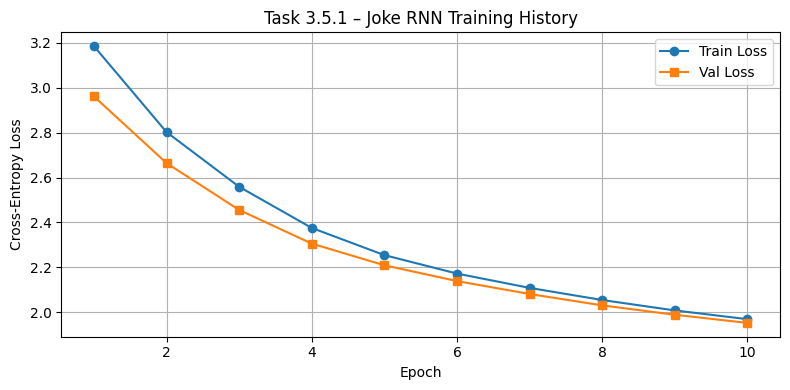

In [16]:
# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS_JOKES + 1), train_losses_jokes, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS_JOKES + 1), val_losses_jokes,   label='Val Loss',   marker='s')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Task 3.5.1 – Joke RNN Training History')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3.5.1 (h) – Generate Jokes

In [17]:
def generate_joke(model, char2int, int2char, seed, length=200, temperature=0.8, device='cpu'):

    model.eval()
    # Filter seed to known characters only
    seed_clean = ''.join(c for c in seed if c in char2int)
    seed_idx   = torch.tensor([[char2int[c] for c in seed_clean]], dtype=torch.long).to(device)

    with torch.no_grad():
        # Warm up hidden state on seed
        _, hidden = model(seed_idx)

        generated = list(seed_clean)
        # Use last character of seed as first input token
        x = seed_idx[:, -1:]

        for _ in range(length):
            logits, hidden = model(x, hidden)  # logits: [1, 1, vocab_size]
            logits = logits[:, -1, :] / temperature
            probs  = torch.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)  # [1, 1]
            next_char = int2char[int(next_idx.item())]
            if next_char == '^':  # skip padding token
                break
            generated.append(next_char)
            x = next_idx

    return ''.join(generated)


# Generate a joke using the specified seed
seed_text = "a data scientist walks into a bar"
generated_joke = generate_joke(
    model_jokes, char2int, int2char,
    seed=seed_text, length=200, temperature=0.8, device=device
)
print("Generated Joke:")
print("-" * 60)
print(generated_joke)
print("-" * 60)

Generated Joke:
------------------------------------------------------------
riondon a man budersed seaten of you pondle coll all a shasered on the dids late 
------------------------------------------------------------


---
# Task 3.5.2 – News Article Generation by Character-Level RNN

## Load AG News Dataset

In [18]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")

# Split train into train and validation (80/20)
temp = dataset["train"].train_test_split(test_size=0.2, seed=42)
dataset['val']   = temp['test']
dataset['train'] = temp['train']

print("Dataset splits:")
for split in ['train', 'val', 'test']:
    print(f"  {split}: {len(dataset[split])} samples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset splits:
  train: 96000 samples
  val: 24000 samples
  test: 7600 samples


## 3.5.2 (a) – Visualize Article Length Distribution & Crop to 300 Characters

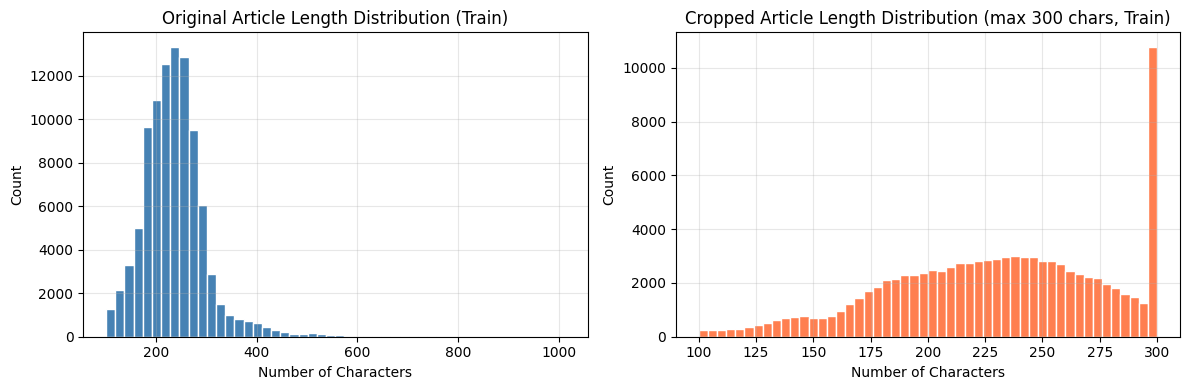

In [19]:
train_texts = dataset['train']['text']
val_texts   = dataset['val']['text']

# Original lengths
train_lengths_orig = [len(t) for t in train_texts]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(train_lengths_orig, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.title('Original Article Length Distribution (Train)')
plt.grid(True, alpha=0.3)

# Crop articles to a maximum of 300 characters
MAX_LEN_NEWS = 300
train_texts_crop = [t[:MAX_LEN_NEWS] for t in train_texts]
val_texts_crop   = [t[:MAX_LEN_NEWS] for t in val_texts]

train_lengths_crop = [len(t) for t in train_texts_crop]

plt.subplot(1, 2, 2)
plt.hist(train_lengths_crop, bins=50, color='coral', edgecolor='white')
plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.title('Cropped Article Length Distribution (max 300 chars, Train)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.5.2 (b) – Build Character Vocabulary & Convert Articles to Indices

In [20]:
# Build vocab from TRAINING articles only
all_train_text_news = ''.join(train_texts_crop)
chars_news = sorted(set(all_train_text_news))
vocab_size_news = len(chars_news)

print(f"Vocabulary size: {vocab_size_news}")

char2int_news = {ch: idx for idx, ch in enumerate(chars_news)}
int2char_news = {idx: ch for idx, ch in enumerate(chars_news)}

PAD_IDX_NEWS = vocab_size_news
char2int_news['^'] = PAD_IDX_NEWS
int2char_news[PAD_IDX_NEWS] = '^'
vocab_size_news_with_pad = vocab_size_news + 1

print(f"Vocabulary size (with padding): {vocab_size_news_with_pad}")
print(f"Character-to-index mapping:")
print(char2int_news)

# Convert articles to index sequences
def text_to_indices(texts, char2int):
    result = []
    for t in texts:
        seq = [char2int[c] for c in t if c in char2int]
        if len(seq) > 0:
            result.append(torch.tensor(seq, dtype=torch.long))
    return result

train_indices_news = text_to_indices(train_texts_crop, char2int_news)
val_indices_news   = text_to_indices(val_texts_crop,   char2int_news)

print(f"\nTraining articles converted: {len(train_indices_news)}")
print(f"Validation articles converted: {len(val_indices_news)}")

Vocabulary size: 82
Vocabulary size (with padding): 83
Character-to-index mapping:
{' ': 0, '!': 1, '"': 2, '#': 3, '$': 4, '&': 5, "'": 6, '(': 7, ')': 8, '*': 9, ',': 10, '-': 11, '.': 12, '/': 13, '0': 14, '1': 15, '2': 16, '3': 17, '4': 18, '5': 19, '6': 20, '7': 21, '8': 22, '9': 23, ':': 24, ';': 25, '=': 26, '?': 27, 'A': 28, 'B': 29, 'C': 30, 'D': 31, 'E': 32, 'F': 33, 'G': 34, 'H': 35, 'I': 36, 'J': 37, 'K': 38, 'L': 39, 'M': 40, 'N': 41, 'O': 42, 'P': 43, 'Q': 44, 'R': 45, 'S': 46, 'T': 47, 'U': 48, 'V': 49, 'W': 50, 'X': 51, 'Y': 52, 'Z': 53, '\\': 54, '_': 55, 'a': 56, 'b': 57, 'c': 58, 'd': 59, 'e': 60, 'f': 61, 'g': 62, 'h': 63, 'i': 64, 'j': 65, 'k': 66, 'l': 67, 'm': 68, 'n': 69, 'o': 70, 'p': 71, 'q': 72, 'r': 73, 's': 74, 't': 75, 'u': 76, 'v': 77, 'w': 78, 'x': 79, 'y': 80, 'z': 81, '^': 82}

Training articles converted: 96000
Validation articles converted: 24000


## 3.5.2 (c) – Pad Articles & Prepare DataLoaders

In [21]:
# Pad to fixed length of 300 characters
FIXED_LEN = 300

def pad_to_fixed(index_list, pad_idx, fixed_len):
    """Pad / truncate each sequence to exactly fixed_len tokens."""
    padded = []
    for seq in index_list:
        if len(seq) < fixed_len:
            pad_amount = fixed_len - len(seq)
            seq = torch.cat([seq, torch.full((pad_amount,), pad_idx, dtype=torch.long)])
        else:
            seq = seq[:fixed_len]
        padded.append(seq)
    return torch.stack(padded)

train_padded_news = pad_to_fixed(train_indices_news, PAD_IDX_NEWS, FIXED_LEN)  # [N, 300]
val_padded_news   = pad_to_fixed(val_indices_news,   PAD_IDX_NEWS, FIXED_LEN)

print(f"Train padded shape: {train_padded_news.shape}")
print(f"Val   padded shape: {val_padded_news.shape}")

# Input = first 299 chars, target = last 299 chars (shifted by 1)
train_input_news  = train_padded_news[:, :-1]   # [N, 299]
train_target_news = train_padded_news[:, 1:]    # [N, 299]
val_input_news    = val_padded_news[:, :-1]
val_target_news   = val_padded_news[:, 1:]

BATCH_SIZE_NEWS = 128

train_ds_news = TensorDataset(train_input_news, train_target_news)
val_ds_news   = TensorDataset(val_input_news,   val_target_news)

train_loader_news = DataLoader(train_ds_news, batch_size=BATCH_SIZE_NEWS, shuffle=True)
val_loader_news   = DataLoader(val_ds_news,   batch_size=BATCH_SIZE_NEWS, shuffle=False)

# Print an example
ex_in_n, ex_tgt_n = train_ds_news[0]
print("\nExample INPUT  sequence (first 50 chars):")
print(''.join([int2char_news[int(i)] for i in ex_in_n[:50]]))
print("\nExample TARGET sequence (first 50 chars):")
print(''.join([int2char_news[int(i)] for i in ex_tgt_n[:50]]))

Train padded shape: torch.Size([96000, 300])
Val   padded shape: torch.Size([24000, 300])

Example INPUT  sequence (first 50 chars):
Nation #39;s Cotton Crop May Exceed Records This y

Example TARGET sequence (first 50 chars):
ation #39;s Cotton Crop May Exceed Records This ye


## 3.5.2 (d) – CharRNN with One-Hot Encoding

In [22]:
class CharRNN_OneHot(nn.Module):
    """
    Character-level RNN using one-hot encoding as input representation.
    """
    def __init__(self, vocab_size, hidden_size, num_layers):
        super().__init__()
        self.vocab_size  = vocab_size
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size  = vocab_size,   # one-hot dimension
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = 0.3 if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x: [B, T]  (integer indices)
        # Convert to one-hot: [B, T, vocab_size]
        x_onehot = torch.nn.functional.one_hot(x, num_classes=self.vocab_size).float()
        out, hidden = self.lstm(x_onehot, hidden)  # [B, T, hidden]
        logits = self.fc(out)                       # [B, T, vocab_size]
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        return (h0, c0)


# Reasonable hyperparameters for the generation task
HIDDEN_SIZE_NEWS_GEN = 256
NUM_LAYERS_NEWS_GEN  = 2
EPOCHS_NEWS_GEN = 10
LR_NEWS_GEN = 0.001

model_news_gen = CharRNN_OneHot(
    vocab_size  = vocab_size_news_with_pad,
    hidden_size = HIDDEN_SIZE_NEWS_GEN,
    num_layers  = NUM_LAYERS_NEWS_GEN
).to(device)

print(model_news_gen)
print(f"\nTotal parameters: {sum(p.numel() for p in model_news_gen.parameters() if p.requires_grad):,}")

CharRNN_OneHot(
  (lstm): LSTM(83, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=83, bias=True)
)

Total parameters: 896,851


## 3.5.2 (e) – Train and Validate the Model

In [23]:
criterion_news_gen = nn.CrossEntropyLoss(ignore_index=PAD_IDX_NEWS)
optimizer_news_gen = optim.Adam(model_news_gen.parameters(), lr=LR_NEWS_GEN)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        logits, _ = model(inputs)
        loss = criterion(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)
            loss = criterion(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)


train_losses_news_gen, val_losses_news_gen = [], []

for epoch in range(1, EPOCHS_NEWS_GEN + 1):
    tr_loss  = train_one_epoch(model_news_gen, train_loader_news, criterion_news_gen, optimizer_news_gen, device)
    val_loss = eval_one_epoch(model_news_gen,  val_loader_news,   criterion_news_gen, device)
    train_losses_news_gen.append(tr_loss)
    val_losses_news_gen.append(val_loss)
    print(f"Epoch {epoch:>2}/{EPOCHS_NEWS_GEN}  |  Train Loss: {tr_loss:.4f}  |  Val Loss: {val_loss:.4f}")

Epoch  1/10  |  Train Loss: 2.6068  |  Val Loss: 2.0786
Epoch  2/10  |  Train Loss: 1.9220  |  Val Loss: 1.7139
Epoch  3/10  |  Train Loss: 1.6687  |  Val Loss: 1.5327
Epoch  4/10  |  Train Loss: 1.5358  |  Val Loss: 1.4342
Epoch  5/10  |  Train Loss: 1.4585  |  Val Loss: 1.3747
Epoch  6/10  |  Train Loss: 1.4083  |  Val Loss: 1.3358
Epoch  7/10  |  Train Loss: 1.3735  |  Val Loss: 1.3049
Epoch  8/10  |  Train Loss: 1.3468  |  Val Loss: 1.2825
Epoch  9/10  |  Train Loss: 1.3263  |  Val Loss: 1.2660
Epoch 10/10  |  Train Loss: 1.3097  |  Val Loss: 1.2510


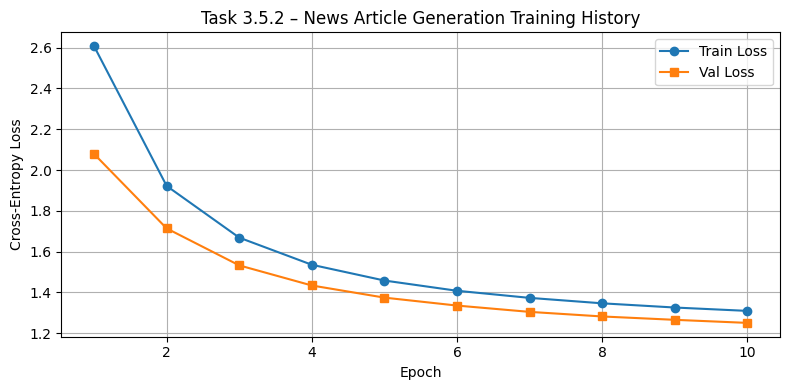

In [24]:
# Plot training and validation history
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS_NEWS_GEN + 1), train_losses_news_gen, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS_NEWS_GEN + 1), val_losses_news_gen,   label='Val Loss',   marker='s')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Task 3.5.2 – News Article Generation Training History')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3.5.2 (f) – Generate Example News Articles

In [25]:
def generate_text(model, char2int, int2char, seed, length=200, temperature=0.8, device='cpu'):

    model.eval()
    seed_clean = ''.join(c for c in seed if c in char2int)
    seed_idx   = torch.tensor([[char2int[c] for c in seed_clean]], dtype=torch.long).to(device)

    with torch.no_grad():
        _, hidden = model(seed_idx)
        generated = list(seed_clean)
        x = seed_idx[:, -1:]

        for _ in range(length):
            logits, hidden = model(x, hidden)
            logits = logits[:, -1, :] / temperature
            probs  = torch.softmax(logits, dim=-1)
            next_idx  = torch.multinomial(probs, num_samples=1)
            next_char = int2char[int(next_idx.item())]
            if next_char == '^':   # padding → stop
                break
            generated.append(next_char)
            x = next_idx

    return ''.join(generated)


# Generate a few example news articles with different seeds
seeds_news = [
    "Scientists discover",
    "The stock market",
    "World leaders met"
]

for seed in seeds_news:
    gen = generate_text(
        model_news_gen, char2int_news, int2char_news,
        seed=seed, length=250, temperature=0.7, device=device
    )
    print(f"Seed: '{seed}'")
    print("-" * 60)
    print(gen)
    print("=" * 60)
    print()

Seed: 'Scientists discover'
------------------------------------------------------------
Scientists discoverate defense at Darfur and sought players today been an explosion that he has been make through the committee and ruling What analysts and interim crashes in the rest of the team behind the first time in the market. The most left security study in the

Seed: 'The stock market'
------------------------------------------------------------
The stock marketly walked to site to rest of a temporary research, President Vladimir Putin and a country #39;s party this year, the prime minister dead in his Web services maker was a demand in the second time behind Thursday after the Boston Red Sox chain. The war

Seed: 'World leaders met'
------------------------------------------------------------
World leaders meting on Thursday after the copyright goal of the Indianapabel John Los Angelise trade said Saturday that he will be have of a deal and the car bombing the United States but a group of

---
# Task 3.5.3 – News Article Classification by Character-Level RNN

## 3.5.3 (a) – Preprocessing (Same as Task 3.5.2)

In [26]:

# Extract texts AND labels for train, val, test
train_texts_cls  = [t[:MAX_LEN_NEWS] for t in dataset['train']['text']]
val_texts_cls    = [t[:MAX_LEN_NEWS] for t in dataset['val']['text']]
test_texts_cls   = [t[:MAX_LEN_NEWS] for t in dataset['test']['text']]

train_labels_cls = dataset['train']['label']
val_labels_cls   = dataset['val']['label']
test_labels_cls  = dataset['test']['label']

print(f"Train: {len(train_texts_cls)} articles")
print(f"Val:   {len(val_texts_cls)} articles")
print(f"Test:  {len(test_texts_cls)} articles")

# Convert to index sequences using the same vocabulary
train_idx_cls = text_to_indices(train_texts_cls, char2int_news)
val_idx_cls   = text_to_indices(val_texts_cls,   char2int_news)
test_idx_cls  = text_to_indices(test_texts_cls,  char2int_news)

Train: 96000 articles
Val:   24000 articles
Test:  7600 articles


## 3.5.3 (b) – Pad Articles & Prepare DataLoaders (batch size = 512, use labels as targets)

In [27]:
# Pad sequences to FIXED_LEN = 300
train_padded_cls = pad_to_fixed(train_idx_cls, PAD_IDX_NEWS, FIXED_LEN)  # [N, 300]
val_padded_cls   = pad_to_fixed(val_idx_cls,   PAD_IDX_NEWS, FIXED_LEN)
test_padded_cls  = pad_to_fixed(test_idx_cls,  PAD_IDX_NEWS, FIXED_LEN)

# Handle possible length mismatch after filtering
n_train_cls = train_padded_cls.shape[0]
n_val_cls   = val_padded_cls.shape[0]
n_test_cls  = test_padded_cls.shape[0]

# Labels as long tensors
train_labels_t = torch.tensor(train_labels_cls[:n_train_cls], dtype=torch.long)
val_labels_t   = torch.tensor(val_labels_cls[:n_val_cls],     dtype=torch.long)
test_labels_t  = torch.tensor(test_labels_cls[:n_test_cls],   dtype=torch.long)

BATCH_SIZE_CLS = 512

train_ds_cls = TensorDataset(train_padded_cls, train_labels_t)
val_ds_cls   = TensorDataset(val_padded_cls,   val_labels_t)
test_ds_cls  = TensorDataset(test_padded_cls,  test_labels_t)

train_loader_cls = DataLoader(train_ds_cls, batch_size=BATCH_SIZE_CLS, shuffle=True)
val_loader_cls   = DataLoader(val_ds_cls,   batch_size=BATCH_SIZE_CLS, shuffle=False)
test_loader_cls  = DataLoader(test_ds_cls,  batch_size=BATCH_SIZE_CLS, shuffle=False)

print(f"Train batches: {len(train_loader_cls)}, Val batches: {len(val_loader_cls)}, Test batches: {len(test_loader_cls)}")

Train batches: 188, Val batches: 47, Test batches: 15


## 3.5.3 (c) – Character-Level RNN for Classification (5 LSTM Layers, Hidden Size 32)

In [28]:
class CharRNN_Classifier(nn.Module):
    """
    Character-level RNN classifier.
    Uses the final hidden state of the LSTM for classification.
    """
    def __init__(self, vocab_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.vocab_size  = vocab_size
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size  = vocab_size,    # one-hot encoding
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = 0.3 if num_layers > 1 else 0.0
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: [B, T] integer indices
        x_onehot = torch.nn.functional.one_hot(x, num_classes=self.vocab_size).float()  # [B, T, V]
        out, (h_n, _) = self.lstm(x_onehot)     # h_n: [num_layers, B, hidden]
        # Use the last layer's final hidden state for classification
        final_hidden = h_n[-1]                   # [B, hidden]
        logits = self.classifier(final_hidden)   # [B, num_classes]
        return logits


# Hyperparameters as specified in the assignment
NUM_LAYERS_CLS  = 5
HIDDEN_SIZE_CLS = 32
NUM_CLASSES     = 4   # World, Sports, Business, Science/Technology

model_cls = CharRNN_Classifier(
    vocab_size  = vocab_size_news_with_pad,
    hidden_size = HIDDEN_SIZE_CLS,
    num_layers  = NUM_LAYERS_CLS,
    num_classes = NUM_CLASSES
).to(device)

print(model_cls)
print(f"\nTotal parameters: {sum(p.numel() for p in model_cls.parameters() if p.requires_grad):,}")

CharRNN_Classifier(
  (lstm): LSTM(83, 32, num_layers=5, batch_first=True, dropout=0.3)
  (classifier): Linear(in_features=32, out_features=4, bias=True)
)

Total parameters: 48,900


## 3.5.3 (d) – Sample One Batch & Print Shapes

In [29]:
# Sample one batch from the training DataLoader
sample_inputs, sample_targets = next(iter(train_loader_cls))
sample_inputs  = sample_inputs.to(device)
sample_targets = sample_targets.to(device)

# Forward pass
model_cls.eval()
with torch.no_grad():
    sample_logits = model_cls(sample_inputs)

print(f"Input   shape : {sample_inputs.shape}   → [batch_size, seq_len]")
print(f"Logits  shape : {sample_logits.shape}  → [batch_size, num_classes]")
print(f"Targets shape : {sample_targets.shape}  → [batch_size]")

Input   shape : torch.Size([512, 300])   → [batch_size, seq_len]
Logits  shape : torch.Size([512, 4])  → [batch_size, num_classes]
Targets shape : torch.Size([512])  → [batch_size]


## 3.5.3 (e) – Train for 10 Epochs (lr=1e-4, Adam) & Plot History

In [30]:
LR_CLS     = 1e-4
EPOCHS_CLS = 10

criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = optim.Adam(model_cls.parameters(), lr=LR_CLS)


def train_epoch_cls(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss   = criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
        preds   = logits.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total   += targets.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch_cls(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = model(inputs)
            loss   = criterion(logits, targets)
            total_loss += loss.item()
            preds   = logits.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total   += targets.size(0)
    return total_loss / len(loader), correct / total


train_losses_cls, val_losses_cls = [], []
train_accs_cls,   val_accs_cls   = [], []

for epoch in range(1, EPOCHS_CLS + 1):
    tr_loss,  tr_acc  = train_epoch_cls(model_cls, train_loader_cls, criterion_cls, optimizer_cls, device)
    val_loss, val_acc = eval_epoch_cls(model_cls,  val_loader_cls,   criterion_cls, device)

    train_losses_cls.append(tr_loss)
    val_losses_cls.append(val_loss)
    train_accs_cls.append(tr_acc)
    val_accs_cls.append(val_acc)

    print(f"Epoch {epoch:>2}/{EPOCHS_CLS}  |  "
          f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

Epoch  1/10  |  Train Loss: 1.3880  Train Acc: 0.2512  |  Val Loss: 1.3863  Val Acc: 0.2475
Epoch  2/10  |  Train Loss: 1.3849  Train Acc: 0.2644  |  Val Loss: 1.3787  Val Acc: 0.3030
Epoch  3/10  |  Train Loss: 1.3764  Train Acc: 0.2973  |  Val Loss: 1.3734  Val Acc: 0.3026
Epoch  4/10  |  Train Loss: 1.3744  Train Acc: 0.2990  |  Val Loss: 1.3728  Val Acc: 0.3071
Epoch  5/10  |  Train Loss: 1.3733  Train Acc: 0.3005  |  Val Loss: 1.3712  Val Acc: 0.3094
Epoch  6/10  |  Train Loss: 1.3499  Train Acc: 0.3253  |  Val Loss: 1.3080  Val Acc: 0.3610
Epoch  7/10  |  Train Loss: 1.3101  Train Acc: 0.3623  |  Val Loss: 1.3065  Val Acc: 0.3574
Epoch  8/10  |  Train Loss: 1.3002  Train Acc: 0.3629  |  Val Loss: 1.2905  Val Acc: 0.3714
Epoch  9/10  |  Train Loss: 1.2952  Train Acc: 0.3705  |  Val Loss: 1.2872  Val Acc: 0.3811
Epoch 10/10  |  Train Loss: 1.2940  Train Acc: 0.3684  |  Val Loss: 1.2835  Val Acc: 0.3836


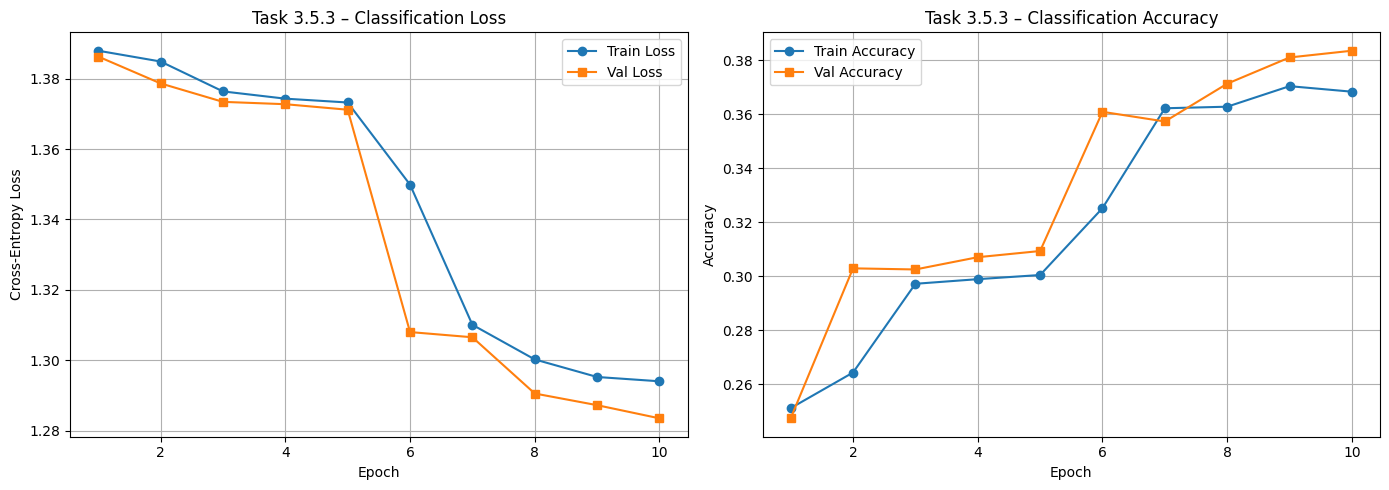

In [31]:
# Plot training and validation history (loss + accuracy)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS_CLS + 1), train_losses_cls, label='Train Loss', marker='o')
axes[0].plot(range(1, EPOCHS_CLS + 1), val_losses_cls,   label='Val Loss',   marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Task 3.5.3 – Classification Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, EPOCHS_CLS + 1), train_accs_cls, label='Train Accuracy', marker='o')
axes[1].plot(range(1, EPOCHS_CLS + 1), val_accs_cls,   label='Val Accuracy',   marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Task 3.5.3 – Classification Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3.5.3 (f) – Evaluate on Test Set

In [32]:
test_loss, test_acc = eval_epoch_cls(model_cls, test_loader_cls, criterion_cls, device)

print("=" * 50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc * 100:.2f}%)")
print("=" * 50)
print()
print("Note: A character-level RNN does not capture semantic meaning")
print("of words and sentences, so accuracy may be below expectations.")
print("Better approaches (e.g., Transformers) will be covered in the next lab.")

Test Loss     : 1.2855
Test Accuracy : 0.3772 (37.72%)

Note: A character-level RNN does not capture semantic meaning
of words and sentences, so accuracy may be below expectations.
Better approaches (e.g., Transformers) will be covered in the next lab.
